In [1]:
# Import PyTorch
import torch
from torch import nn
import torch.optim as optim

# Import torchvision 
import torchvision
from torchvision import datasets, transforms
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader
from torchsummary import summary

import os
import random
import matplotlib.pyplot as plt
from PIL import Image
from torchvision.models import resnet18, ResNet18_Weights, resnet50, ResNet50_Weights

In [2]:
"""
    1. Direct use of pretrained model with ResNet50.
"""

# Select pretrained weights
weights50 = ResNet50_Weights.DEFAULT

# Load the pretrained ResNet50 model
model50 = resnet50(weights=weights50)

# Set the model to evaluation mode
model50.eval()


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = model50.to(device)
print(f"Using device: {device}")

categories = weights50.meta["categories"]
print(f"Number of classes: {len(categories)}")
print(categories[:10])

Using device: cpu
Number of classes: 1000
['tench', 'goldfish', 'great white shark', 'tiger shark', 'hammerhead', 'electric ray', 'stingray', 'cock', 'hen', 'ostrich']


In [4]:
from PIL import Image
image_path = "C:/Users/Majid/data/Cats_and_Dogs/predict/cat-3.jfif"
image = Image.open(image_path).convert("RGB")
print(image.size)

(287, 175)


In [5]:
def predict_image(model, image_path, weights, device):
    
    # Step 1: Get the preprocessing transformations
    preprocess = weights.transforms()
    
    # Step 2: Get the class names
    categories = weights.meta["categories"]
    
    # Step 3: Open the image
    image = Image.open(image_path).convert("RGB")
    
    # Step 4: Preprocess the image
    input_tensor = preprocess(image)
    
    # Step 5: Add batch dimension
    # The shape changes from: (C, H, W) to (1, C, H, W)
    input_batch = input_tensor.unsqueeze(0).to(device)
    
    # Step 6: Set model to evaluation mode
    model.eval()
    
    # Step 7: Make prediction
    with torch.no_grad():
        output = model(input_batch)
        
    # Step 8: Convert logits to probabilities
    probabilities = torch.softmax(output, dim=1)
    
    # Step 9: Find the predicted class
    predicted_class_index = probabilities.argmax(dim=1).item()
    
    # Step 10: Get class name and probability
    predicted_class = categories[predicted_class_index]
    predicted_probability = probabilities[0, predicted_class_index].item()
    
    return predicted_class, predicted_probability

In [6]:
image_path = "C:/Users/Majid/data/Cats_and_Dogs/predict/dog_98.jpg"

predicted_class, probability = predict_image(
    model=model50,
    image_path=image_path,
    weights=weights50,
    device=device
)
print(
    f"Prediction: {predicted_class} "
    f"(probability={probability:.4f})"
)

Prediction: beagle (probability=0.4232)


In [7]:
# Setup train and testing paths
train_dir = "C:/Users/Majid/data/Cats_and_Dogs/train"
test_dir = "C:/Users/Majid/data/Cats_and_Dogs/test"

In [8]:
"""
    2. Feature Extraction with ResNet18.
"""

# Load Pretrained ResNet18 Weights
weights18 = ResNet18_Weights.DEFAULT

# Load the pretrained ResNet18 model
model18 = resnet18(weights=weights18).to(device)

#Get the preprocessing transformations
preprocess18 = weights18.transforms()

print(preprocess18)


ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


In [9]:
def create_transform(weights):
    preprocess = weights.transforms()

    # We can add data augmentation for train data
    train_transform = transforms.Compose([
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.TrivialAugmentWide(num_magnitude_bins=40),
        preprocess
    ])

    # We cannot add data augmentation for test data
    test_transform = weights.transforms()

    return train_transform, test_transform


In [10]:
def create_datasets(train_dir, test_dir, weights):
    train_transform, test_transform = create_transform(weights)

    train_dataset = datasets.ImageFolder(
        root=train_dir,
        transform=train_transform
    )

    test_dataset = datasets.ImageFolder(
        root=test_dir,
        transform=test_transform
    )

    return train_dataset, test_dataset

In [11]:
train_dataset, test_dataset = create_datasets(
    train_dir=train_dir,
    test_dir=test_dir,
    weights=weights18
)

In [12]:
print(train_dataset.class_to_idx)
print(f"Training images: {len(train_dataset)}")
print(f"Test images: {len(test_dataset)}")

{'cats': 0, 'dogs': 1}
Training images: 555
Test images: 138


In [13]:
def create_dataloaders(
    train_dataset,
    test_dataset,
    batch_size=32
):
    train_dataloader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True
    )

    test_dataloader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False
    )

    return train_dataloader, test_dataloader

In [14]:
train_loader, test_loader = create_dataloaders(
    train_dataset=train_dataset,
    test_dataset=test_dataset,
    batch_size=32
)

In [15]:
# Freeze all pretrained parameters
for param in model18.parameters():
    param.requires_grad = False

# Replace the final classification layer
num_features = model18.fc.in_features
model18.fc = nn.Linear(num_features, 1)

# Optimize only the new classifier
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(
    model18.fc.parameters(),
    lr=0.001
)


In [16]:
for name, param in model18.named_parameters():
    if param.requires_grad:
        print(name)

fc.weight
fc.bias


In [17]:
model18 = model18.to(device)

In [18]:
def accuracy_fn(y_true, y_pred):
    probabilities = torch.sigmoid(y_pred)
    predictions = (probabilities > 0.5).float()
    correct = (predictions == y_true).float().sum()
    accuracy = correct / len(y_true)
    return accuracy * 100

In [19]:
def train_model(
    model, 
    train_loader, 
    test_loader,
    optimizer,
    criterion = nn.BCEWithLogitsLoss(),
    epochs=10, 
    learning_rate = 0.0001
):
    train_losses, test_losses, train_accuracies, test_accuracies = [], [], [], []

    for epoch in range(epochs):
        model.train()
        epoch_train_loss, epoch_train_acc = 0., 0.

        # ---- TRAINING LOOP ----
        for batch_features, batch_targets in train_loader:
            # shape: [batch_size, 1]
            batch_features, batch_targets = batch_features.to(device), batch_targets.unsqueeze(1).float().to(device)

            # 1.
            optimizer.zero_grad()

            # 2. Prediction (Forward pass)
            batch_predictions = model(batch_features)

            # 3. Compute loss and accuracy
            batch_loss = criterion(batch_predictions, batch_targets)
            batch_acc = accuracy_fn(batch_targets, batch_predictions)

            batch_loss.backward()
            optimizer.step()

            epoch_train_loss += batch_loss.item()
            epoch_train_acc += batch_acc

        # Average over all batches
        epoch_train_loss /= len(train_loader)
        epoch_train_acc /= len(train_loader)

        # ---- EVALUATION LOOP ----
        model.eval()
        epoch_test_loss, epoch_test_acc = 0., 0.
        with torch.no_grad():
            for batch_features, batch_targets in test_loader:
                # shape: [batch_size, 1]
                batch_features, batch_targets = batch_features.to(device), batch_targets.unsqueeze(1).float().to(device)
                
                batch_predictions = model(batch_features)
                batch_loss = criterion(batch_predictions, batch_targets)
                batch_acc = accuracy_fn(batch_targets, batch_predictions)

                epoch_test_loss += batch_loss.item()
                epoch_test_acc += batch_acc

        epoch_test_loss /= len(test_loader)
        epoch_test_acc /= len(test_loader)

        # Store results
        train_losses.append(epoch_train_loss)
        test_losses.append(epoch_test_loss)
        train_accuracies.append(epoch_train_acc)
        test_accuracies.append(epoch_test_acc)

        # Print all epochs
        if epoch % 1 == 0:
            print(f"Epoch [{epoch}/{epochs}] | "
                  f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.2f}% | "
                  f"Test Loss: {epoch_test_loss:.4f} | Test Acc: {epoch_test_acc:.2f}%")

    return train_losses, test_losses, train_accuracies, test_accuracies

In [20]:
train_losses_FE, test_losses_FE, train_accuracies_FE, test_accuracies_FE = train_model( 
    model = model18,
    train_loader = train_loader,
    test_loader = test_loader,
    optimizer = optimizer,
    criterion = criterion,
    epochs=10, 
    learning_rate = 0.0001
)

Epoch [0/10] | Train Loss: 0.6015 | Train Acc: 66.68% | Test Loss: 0.4042 | Test Acc: 92.38%
Epoch [1/10] | Train Loss: 0.4315 | Train Acc: 86.70% | Test Loss: 0.2761 | Test Acc: 93.12%
Epoch [2/10] | Train Loss: 0.3400 | Train Acc: 87.34% | Test Loss: 0.2357 | Test Acc: 100.00%
Epoch [3/10] | Train Loss: 0.2913 | Train Acc: 90.80% | Test Loss: 0.1872 | Test Acc: 96.25%
Epoch [4/10] | Train Loss: 0.2595 | Train Acc: 90.64% | Test Loss: 0.1810 | Test Acc: 99.38%
Epoch [5/10] | Train Loss: 0.2327 | Train Acc: 92.57% | Test Loss: 0.1525 | Test Acc: 95.00%
Epoch [6/10] | Train Loss: 0.2264 | Train Acc: 91.00% | Test Loss: 0.1339 | Test Acc: 99.38%
Epoch [7/10] | Train Loss: 0.2413 | Train Acc: 89.80% | Test Loss: 0.1255 | Test Acc: 99.38%
Epoch [8/10] | Train Loss: 0.1958 | Train Acc: 93.43% | Test Loss: 0.1224 | Test Acc: 96.25%
Epoch [9/10] | Train Loss: 0.1950 | Train Acc: 92.39% | Test Loss: 0.1160 | Test Acc: 98.75%


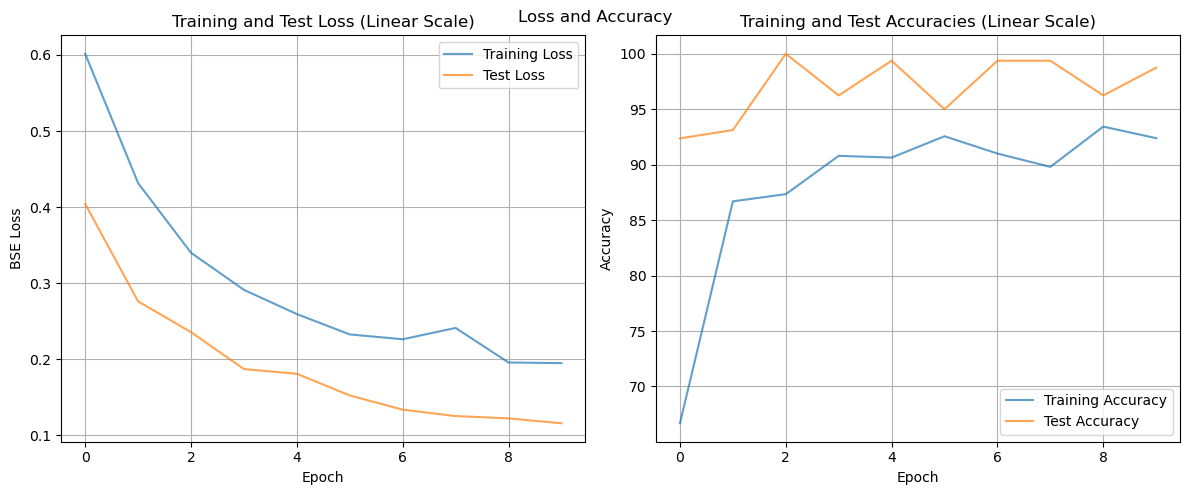

In [21]:
# Plot training and test losses
def plot_loss_accuracy(train_losses, test_losses, train_accuracies, test_accuracies, alpha=0.7):

    fig, axes = plt.subplots(1,2,figsize=(12, 5)) 

    axes[0].plot(train_losses, label='Training Loss', alpha=0.7)
    axes[0].plot(test_losses, label='Test Loss', alpha=0.7)
    axes[0].set_title("Training and Test Loss (Linear Scale)")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("BSE Loss")
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(train_accuracies, label='Training Accuracy', alpha=0.7)
    axes[1].plot(test_accuracies, label='Test Accuracy', alpha=0.7)
    axes[1].set_title("Training and Test Accuracies (Linear Scale)")
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(True)

    # Adjust spacing between subplots
    plt.tight_layout()
    
    fig.suptitle('Loss and Accuracy')

    plt.show()

plot_loss_accuracy(train_losses_FE, test_losses_FE, train_accuracies_FE, test_accuracies_FE)

In [22]:
def predict_image_FE(
    model,
    image_path,
    weights,
    device
):

    # Get preprocessing transformations
    preprocess = weights.transforms()

    # Load image
    image = Image.open(image_path).convert("RGB")

    # Apply preprocessing
    input_tensor = preprocess(image)

    # Add batch dimension
    input_batch = input_tensor.unsqueeze(0)

    # Move input to device
    input_batch = input_batch.to(device)

    # Evaluation mode
    model.eval()

    with torch.no_grad():

        # Forward pass
        output = model(input_batch)

        # Convert logit to probability
        probability = torch.sigmoid(output).item()

    # Convert probability to class
    if probability >= 0.5:
        predicted_class = "Dog"
    else:
        predicted_class = "Cat"

    return predicted_class, probability

In [23]:
image_path = "C:/Users/Majid/data/Cats_and_Dogs/predict/dog_98.jpg"

predicted_class, probability = predict_image_FE(
    model=model18,
    image_path=image_path,
    weights=weights18,
    device=device
)

print(
    f"Prediction: {predicted_class} "
    f"(probability={probability:.4f})"
)

Prediction: Dog (probability=0.9887)


In [24]:
"""
    3. Fine Tuning with ResNet18.
"""

# Load pretrained ResNet18 weights
weights18 = ResNet18_Weights.DEFAULT

# Load the pretrained ResNet18 model
model18_ft = resnet18(weights=weights18)

# Move model to device
model18_ft = model18_ft.to(device)

In [25]:
# Freeze all pretrained parameters
for param in model18_ft.parameters():
    param.requires_grad = False

# Unfreeze the final ResNet block
for param in model18_ft.layer4.parameters():
    param.requires_grad = True

# Replace the final fully connected layer
num_features = model18_ft.fc.in_features
model18_ft.fc = nn.Linear(num_features, 1)

In [26]:
# Check Which Layers Are Trainable
for name, param in model18_ft.named_parameters():
    if param.requires_grad:
        print(name)

layer4.0.conv1.weight
layer4.0.bn1.weight
layer4.0.bn1.bias
layer4.0.conv2.weight
layer4.0.bn2.weight
layer4.0.bn2.bias
layer4.0.downsample.0.weight
layer4.0.downsample.1.weight
layer4.0.downsample.1.bias
layer4.1.conv1.weight
layer4.1.bn1.weight
layer4.1.bn1.bias
layer4.1.conv2.weight
layer4.1.bn2.weight
layer4.1.bn2.bias
fc.weight
fc.bias


In [27]:
# Move model to device
model18_ft = model18_ft.to(device)

In [28]:
# Loss function
criterion = nn.BCEWithLogitsLoss()

# Optimizer
optimizer_ft = optim.Adam(
    filter(lambda p: p.requires_grad, model18_ft.parameters()),
    lr=0.0001
)

In [29]:
# Check the Number of Trainable Parameters
total_params = sum(
    p.numel() for p in model18_ft.parameters()
)

trainable_params = sum(
    p.numel() for p in model18_ft.parameters()
    if p.requires_grad
)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Total parameters: 11,177,025
Trainable parameters: 8,394,241


In [30]:
# We can reuse the train_loader and test_loader from your previous feature-extraction lecture:
train_losses_FT, test_losses_FT, train_accuracies_FT, test_accuracies_FT = train_model(
    model=model18_ft,
    train_loader=train_loader,
    test_loader=test_loader,
    optimizer=optimizer_ft,
    criterion=criterion,
    epochs=5,
    learning_rate=0.0001
) 

Epoch [0/5] | Train Loss: 0.2825 | Train Acc: 88.57% | Test Loss: 0.1180 | Test Acc: 96.88%
Epoch [1/5] | Train Loss: 0.1804 | Train Acc: 94.51% | Test Loss: 0.0771 | Test Acc: 98.12%
Epoch [2/5] | Train Loss: 0.0777 | Train Acc: 97.40% | Test Loss: 0.0954 | Test Acc: 96.88%
Epoch [3/5] | Train Loss: 0.0731 | Train Acc: 97.22% | Test Loss: 0.0860 | Test Acc: 97.50%
Epoch [4/5] | Train Loss: 0.0794 | Train Acc: 96.35% | Test Loss: 0.0817 | Test Acc: 98.12%


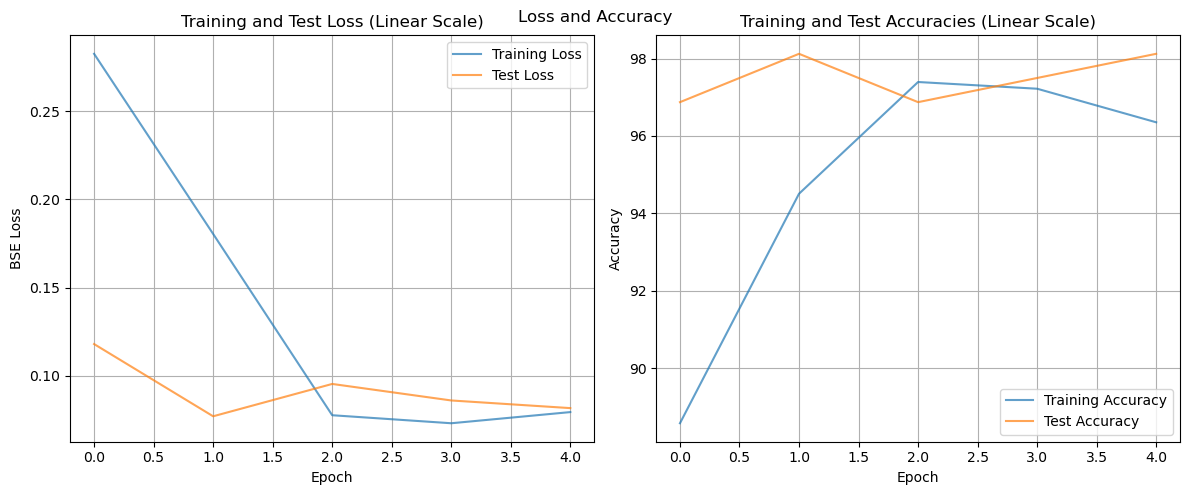

In [31]:
plot_loss_accuracy(
    train_losses_FT,
    test_losses_FT,
    train_accuracies_FT,
    test_accuracies_FT
)

In [32]:
image_path = "C:/Users/Majid/data/Cats_and_Dogs/predict/dog_98.jpg"
predicted_class, probability = predict_image_FE(
    model=model18_ft,
    image_path=image_path,
    weights=weights18,
    device=device
)

print(
    f"Prediction: {predicted_class} "
    f"(probability={probability:.4f})"
)

Prediction: Dog (probability=0.9996)
